# Модель для предсказания массы морских черепах



Критически важно точно знать массу каждой черепахи, чтобы провести им реабилитацию и затем выпустить обратно в океан. Традиционное взвешивание крупной, активной, а иногда травмированной морской черепахи — это огромный стресс для животного и риск для персонала. Партнёры центра «Тортилла» из «Лаборатории перспективных технологий института океанографии» разработали портативную систему компьютерного зрения TurtleCV, которая будет бесконтактно измерять габариты черепах. Опытный образец модели разрабатывается для зелёных морских черепах *Chelonia mydas*.

**Задача** — разработать модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

Модель поможет:
* сократит стресс для уязвимых животных;
* увеличит частоту и безопасность мониторинга их массы;
* позволит оптимизировать лечение и уход, повышая шансы на успешную реабилитацию;
* сделает возможным сбор более полных и точных данных для научного исследования популяций.

## Постановка задачи машинного обучения

* Небходимо разработать модель линейной регрессии, которая будет использовать габариты и другие данные для предсказания массы черепах, полученные коэффициенты в дальнейшем будут использованы для простой функции прогнозирования;


* Целевая переменная - `weight`, масса черепахи, кг;


* Планируемые метрики качества модели:
     * **MAE** (Mean Absolute Error) - средняя абсолютная ошибка. Это функция потерь, которая вычисляет среднее значение абсолютных отклонений между предсказаниями модели (в кг) и фактическим значением целевой переменнной.
     * **MAPE** (Mean Absolute Percentage Error) - cредняя абсолютная процентная ошибка. Оценивает ошибку в относительном выражении (%), что важно для сравнения качества на черепахах разного размера.
     * **R²** - коэффициент детерминации. Показывает, какую долю вариативности целевой переменной объясняет модель. Для уверенности в качестве модели необходимо высокое значение этого коэффициента.
     
     
* Критерии успешного проекта с опорой на метрики:
    * Модель линейная, она должна уметь предсказывать массу черепах разного возраста и  размера;
    * В тестовой выборке должно быть 20% от предоставленных в датасете наблюдений;
    * Обеспечена воспроизводимость экспериментов через фиксацию random_state;
    * МАЕ <= 5 для взрослых особей зелёной морской черепахи в диапазоне масс 50–150 кг;
    * Низкое значение MAPE, показывающее, что ошибка модели масштабируется по размеру черепахи;
    * R² >= 0.97 на валидационной и на тестовой выборках.

## Подключение и настройка библиотек

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
!pip install phik -q
from phik import phik_matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

Файл /datasets/turtles.csv содержит информацию о черепахах:

* `id` — идентификатор измерения.
* `binomial_name` — международное научное название вида черепахи.
* `registration_number` — регистрационный номер черепахи.
* `shell_length` — длина панциря, мм.
* `shell_width` — ширина панциря, мм.
* `head_length` — длина головы, мм.
* `head_width` — ширина головы, мм.
* `flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
* `flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
* `circle_count` — количество колец роста на панцире черепахи.
* `measure_count` — количество измерений по модели компьютерного зрения перед усреднением показателей.
* `shell_crack` — наличие трещин панциря.
* `timestamp` — время внесения данных о черепахе.
* `weight` — масса черепахи, кг.

**Длина должна быть в миллиметрах, некоторые данные длины домнножены на 10!**

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')

In [3]:
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

In [5]:
df.describe()

,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
count,8861.000000,8774.000000,8861.000000,8715.000000,8715.000000,8861.000000,8861.000000,8861.000000,8861.000000,8760.000000,8760.000000,8760.000000,8760.000000,8861.000000,8597.000000,2176.000000,8.861000e+03,8842.000000
mean,21359.335628,764.222020,598.832299,123.341021,115.735169,497.551405,380.594515,498.228530,380.687507,397.953196,304.405251,397.853196,305.030023,41.002821,2.477143,1.671415,1.712640e+09,79.163138
std,2263.089420,640.408681,480.970492,67.836566,62.326365,353.575213,214.481679,355.074883,213.485239,282.970532,171.172490,281.983591,171.540535,36.995874,1.116564,1.131790,2.292273e+07,95.877609
min,17438.000000,132.000000,78.000000,19.000000,12.000000,60.000000,34.000000,57.000000,33.000000,50.000000,27.000000,44.000000,25.000000,0.000000,1.000000,1.000000,1.672570e+09,0.000000
25%,19396.000000,440.000000,341.000000,73.000000,67.000000,296.000000,228.000000,296.000000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,1.000000,1.693001e+09,31.109500
50%,21357.000000,635.000000,487.000000,106.000000,98.000000,416.000000,332.000000,417.000000,330.000000,333.000000,264.000000,333.000000,266.000000,35.000000,2.000000,1.000000,1.712804e+09,41.140500
75%,23317.000000,951.000000,794.000000,158.000000,156.000000,571.000000,493.000000,572.000000,500.000000,457.000000,397.000000,456.000000,396.000000,73.000000,3.000000,2.000000,1.732902e+09,85.239500
max,25279.000000,20240.000000,11550.000000,515.000000,382.000000,2875.000000,1479.000000,2967.000000,1402.000000,2279.000000,1280.000000,2406.000000,1313.000000,178.000000,4.000000,5.000000,1.751608e+09,617.777000


In [6]:
df['shell_length'].describe()

count     8774.000000
mean       764.222020
std        640.408681
min        132.000000
25%        440.000000
50%        635.000000
75%        951.000000
max      20240.000000
Name: shell_length, dtype: float64

In [7]:
def show_missing_stats(temp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Количество пропусков': temp0.isna().sum(),
        'Доля пропусков': temp0.isnull().mean()
    })
    
    if missing_stats.empty:
        return 'Пропусков в данных нет'
    
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Количество пропусков,Доля пропусков
id,0,0.0000
binomial_name,49,0.0055
registration number,29,0.0033
shell_length,87,0.0098
shell_width,0,0.0000
head_length,146,0.0165
head_width,146,0.0165
flipper_length_1,0,0.0000
flipper_width_1,0,0.0000
flipper_length_2,0,0.0000


**Промежуточный вывод:**

* Датасет `/datasets/turtles.csv` содержит 20 столбцов и 8861 строку, в котором содержится информация о черепахах, объем данных -  1.4+ MB;
* Пропусков довольно много, они встречаются в столбцах: `binomial_name`, `registration number`, `shell_length`, `head_length`, `head_width`, `flipper_length_3`, `flipper_width_3`, `flipper_length_4`, `flipper_width_4`, `measure_count`, `shell_crack` (очень много пропусков, 75% всех данных), `weight`;
* Столбцы носят корректные названия, подходящие для анализа данных, приведены в нижнему регистру, но не все в единомом виде snake case, поэтому необходимо преобразовать;
* Представленные данные хранятся в: object, int64 и float64. Носят корректный тип данных;
* Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. НО, Длина должна быть в миллиметрах (так и есть), но некоторые данные длины домнножены на 10!, нужно это учитывать при работе с датасетом;
* При преобработке данных необходимо привести столбецы к виду - snake case, изучить пропуски, аномалии, min, max, проверить столбцы с длиной и сократить на 10, там где необходимо, изучить виды черепах и оставить приоритетный *Chelonia mydas*, вывести диапазон черепах, должно быть 50–150 кг для взрослых особей.
* Некоторые признаки не оказывают влияния на целевую переменную, например, `registration_number`, `binomial_name` и тд.

## Исследовательский анализ данных

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [9]:
tmp = df.copy() 
len(tmp)

8861

In [10]:
df['binomial_name'].value_counts()

Lepidochelys olivacea     3372
Chelonia mydas            2325
Caretta caretta            674
lepidochelys olivacea      416
Dermochelys coriacea       399
Eretmochelys imbricata     332
Lepidochelys Olivacea      285
chelonia mydas             252
Chelonia Mydas             177
LEPIDOCHELYS OLIVACEA      142
caretta caretta             90
CHELONIA MYDAS              75
Caretta Caretta             46
eretmochelys imbricata      41
dermochelys coriacea        40
CARETTA CARETTA             37
Eretmochelys Imbricata      28
Dermochelys Coriacea        27
Lepidochelys kempii         22
DERMOCHELYS CORIACEA        18
ERETMOCHELYS IMBRICATA       8
lepidochelys kempii          3
Lepidochelys Kempii          3
Name: binomial_name, dtype: int64

Виды черепах записаны в разных регистрах, приведем к единому виду и выведем уникальные названия:

In [11]:
df['binomial_name'] = df['binomial_name'].str.lower().str.strip()

df['binomial_name'].value_counts()

lepidochelys olivacea     4215
chelonia mydas            2829
caretta caretta            847
dermochelys coriacea       484
eretmochelys imbricata     409
lepidochelys kempii         28
Name: binomial_name, dtype: int64

In [12]:
df = df[df['binomial_name'] == 'chelonia mydas'].copy()

In [13]:
col_to_drop = [
    'id',
    'binomial_name',
    'registration_number',
    'measure_count',
    'shell_crack',
    'timestamp'
]

df = df.drop(columns=col_to_drop)

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2794 non-null   float64
 1   shell_width       2829 non-null   int64  
 2   head_length       2790 non-null   float64
 3   head_width        2790 non-null   float64
 4   flipper_length_1  2829 non-null   int64  
 5   flipper_width_1   2829 non-null   int64  
 6   flipper_length_2  2829 non-null   int64  
 7   flipper_width_2   2829 non-null   int64  
 8   flipper_length_3  2798 non-null   float64
 9   flipper_width_3   2798 non-null   float64
 10  flipper_length_4  2798 non-null   float64
 11  flipper_width_4   2798 non-null   float64
 12  circle_count      2829 non-null   int64  
 13  weight            2826 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 331.5 KB


In [14]:
changes = len(tmp) - len(df)
print(changes)

6032


**Анализ удаленных признаков:**
* `id` - идентификатор измерения не несет смысла для пргноза;
* `binomial_name` - международное научное название вида черепахи. После фильтрации остался только один вид *chelonia mydas*, поэтому столбец для работы больше не нужен;
* `registration_number` - регистрационный номер черепахи не влияет на массу;
* `measure_count` и `timestamp` - количество измерений и время внесения данных о черепахе не влияет на целевую переменную;
* `shell_crack` - трещина на панцире может влиять на массу, например, они бывают чаще у старых или травмированных черепах, которые могут иметь иной вес, но связь в таком случае слабая и нелинейная. Также трещины фиксируют чаще у черепах в реабилитации, где масса может быть ниже нормы, поэтому это смещающий фактор, а не предиктор. Связь между `shell_crack` и `weight` косвенная и слабая. Основные предикторы массы — это геометрические размеры (длина, ширина панциря, ласт, головы). Пропусков в этом столбце большое количество (75% всех данных), потерять такой объем данных - недопустимо, если заменять другим значением, то внесем сильный шум, который ухудшит коэффициенты.


* После сортировки по виду черепах, необходимому для дальнейшей работы и удаления ненужных столбцов, которые не влияют на целевую переменную, датасет стал состоять из 8 столбов и 2829 строк.

In [15]:
def show_missing_stats(temp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Количество пропусков': temp0.isna().sum(),
        'Доля пропусков': temp0.isnull().mean()
    })
    
    if missing_stats.empty:
        return 'Пропусков в данных нет'
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Количество пропусков,Доля пропусков
shell_length,35,0.0124
shell_width,0,0.0000
head_length,39,0.0138
head_width,39,0.0138
flipper_length_1,0,0.0000
flipper_width_1,0,0.0000
flipper_length_2,0,0.0000
flipper_width_2,0,0.0000
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110


In [16]:
df = df.dropna(subset=['weight'])

In [17]:
duplicates_count = df.duplicated().sum()
print(f'Количество полных дубликатов: {duplicates_count}')
print(f'Процент дубликатов: {duplicates_count/len(df) * 100:.2f}%')

Количество полных дубликатов: 340
Процент дубликатов: 12.03%


In [18]:
duplicates = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
display(duplicates.head(10))

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
7579,683.0,661,96.0,133.0,459,379,422,380,322.0,329.0,364.0,319.0,80,50.982
8598,683.0,661,96.0,133.0,459,379,422,380,322.0,329.0,364.0,319.0,80,50.982
7704,685.0,661,95.0,102.0,403,338,442,395,351.0,342.0,346.0,285.0,70,50.291
8723,685.0,661,95.0,102.0,403,338,442,395,351.0,342.0,346.0,285.0,70,50.291
7655,686.0,616,112.0,123.0,396,435,431,358,321.0,291.0,280.0,322.0,66,49.230
8674,686.0,616,112.0,123.0,396,435,431,358,321.0,291.0,280.0,322.0,66,49.230
6997,686.0,684,126.0,109.0,509,534,442,379,378.0,337.0,380.0,320.0,78,54.954
8016,686.0,684,126.0,109.0,509,534,442,379,378.0,337.0,380.0,320.0,78,54.954
7549,689.0,647,128.0,141.0,406,428,467,402,350.0,275.0,346.0,271.0,70,53.193
8568,689.0,647,128.0,141.0,406,428,467,402,350.0,275.0,346.0,271.0,70,53.193


In [19]:
df = df.drop_duplicates(keep='first')

print(f'Количество полных дубликатов после удаления: {df.duplicated().sum()}')

Количество полных дубликатов после удаления: 0


In [20]:
features = ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_length_2', 'flipper_length_3', 'flipper_length_4', 'flipper_width_1', 'flipper_width_2', 'flipper_width_3', 'flipper_width_4', 'circle_count']

display(df[features].describe())

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_length_2,flipper_length_3,flipper_length_4,flipper_width_1,flipper_width_2,flipper_width_3,flipper_width_4,circle_count
count,2457.000000,2486.000000,2451.000000,2451.000000,2486.000000,2486.000000,2457.000000,2457.000000,2486.000000,2486.000000,2457.000000,2457.000000,2486.000000
mean,1047.963777,945.018101,169.723378,183.321093,612.010459,611.890185,487.262922,489.176231,549.364441,550.253017,440.667481,440.975173,80.931617
std,568.694898,507.521189,41.335454,45.477540,142.589526,138.991986,110.435270,112.562973,131.859104,130.856316,105.532073,104.573836,16.228851
min,645.000000,564.000000,87.000000,96.000000,339.000000,327.000000,282.000000,254.000000,245.000000,276.000000,231.000000,243.000000,29.000000
25%,837.000000,752.250000,138.000000,148.000000,502.000000,505.000000,400.000000,400.000000,449.000000,449.000000,357.000000,359.000000,70.000000
50%,980.000000,889.000000,163.000000,176.000000,587.000000,591.000000,473.000000,473.000000,527.000000,533.000000,425.000000,423.000000,80.000000
75%,1172.000000,1056.000000,195.000000,212.000000,702.000000,704.000000,558.000000,563.000000,632.000000,635.000000,511.000000,509.000000,91.000000
max,12840.000000,11550.000000,328.000000,382.000000,1147.000000,1049.000000,934.000000,877.000000,1072.000000,997.000000,837.000000,806.000000,143.000000


In [21]:
df['weight'].describe()

count    2486.000000
mean       96.068853
std        35.149431
min         0.000000
25%        67.500750
50%        87.900000
75%       117.629500
max       199.961000
Name: weight, dtype: float64

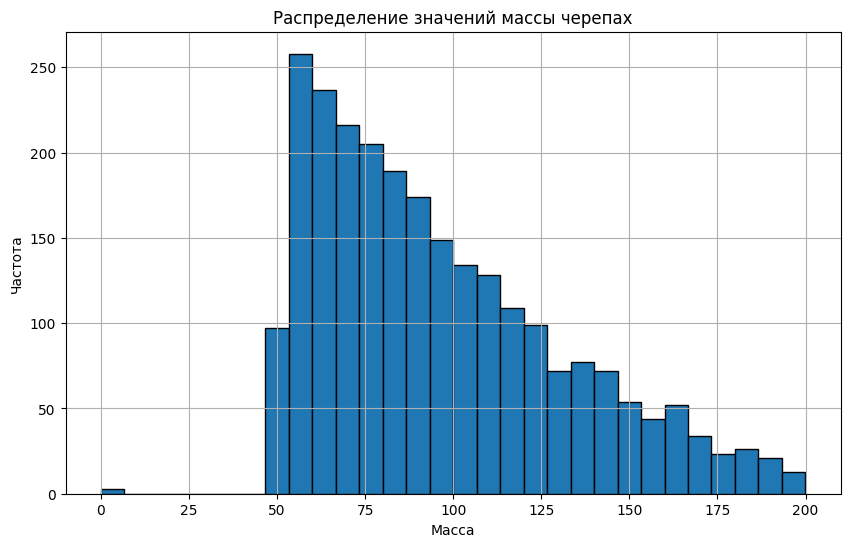

In [22]:
plt.figure(figsize=(10, 6))

df['weight'].plot(
    kind='hist',
    bins=30,
    edgecolor='black',
    rot=0
)
plt.title('Распределение значений массы черепах')
plt.xlabel('Масса')
plt.ylabel('Частота')
plt.grid()

plt.show()

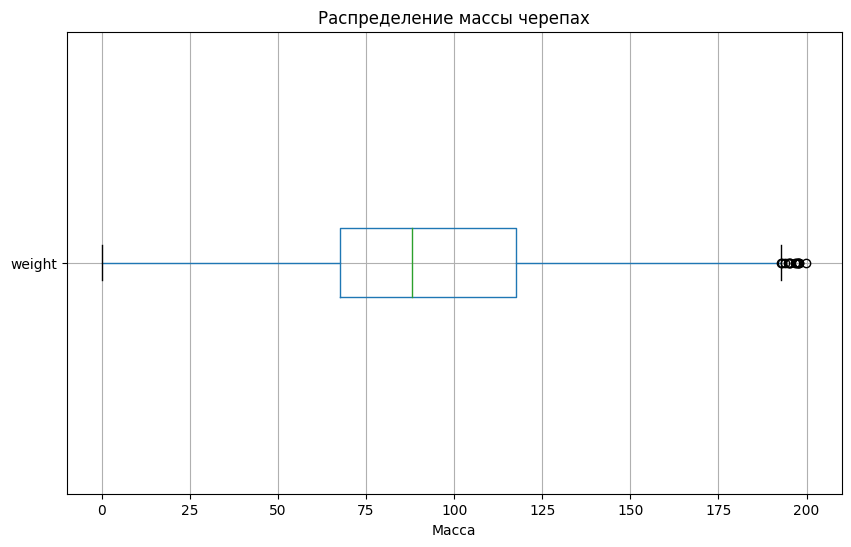

In [23]:
plt.figure(figsize=(10,6))

df.boxplot(column='weight', vert=False)

plt.title('Распределение массы черепах')
plt.xlabel('Масса')

plt.show()

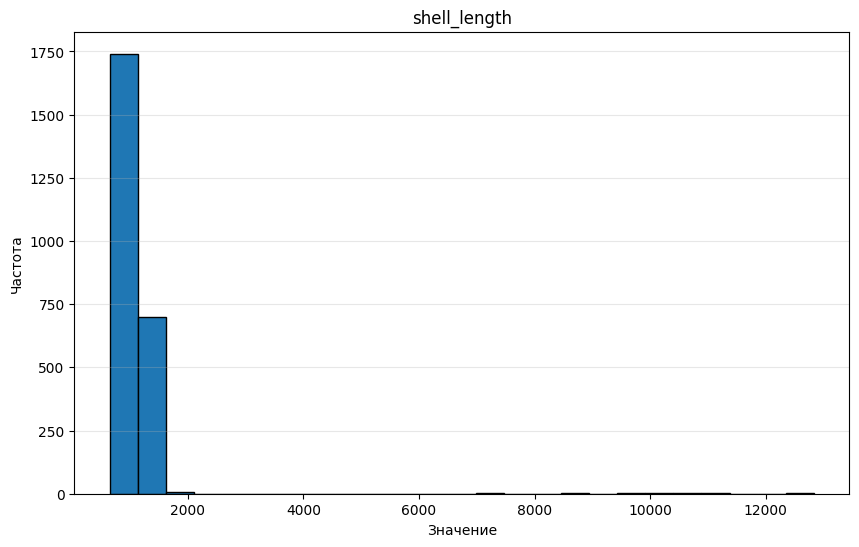

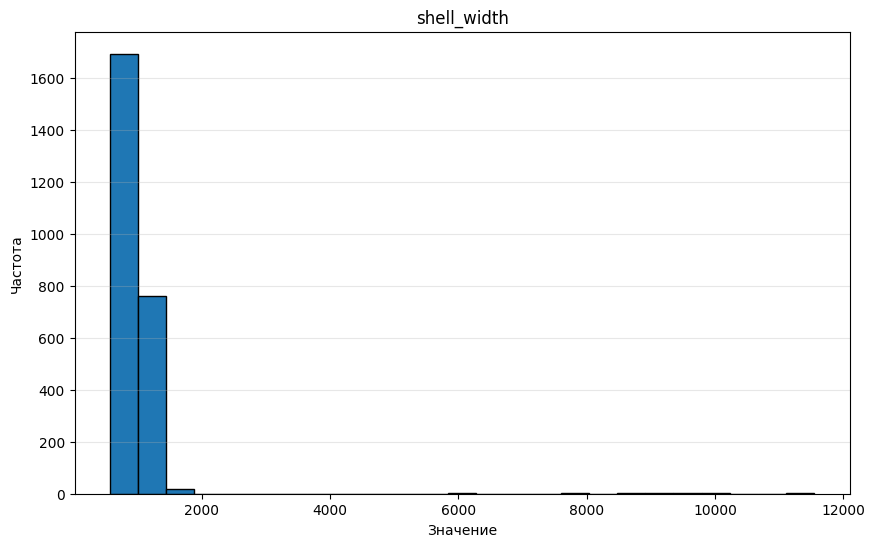

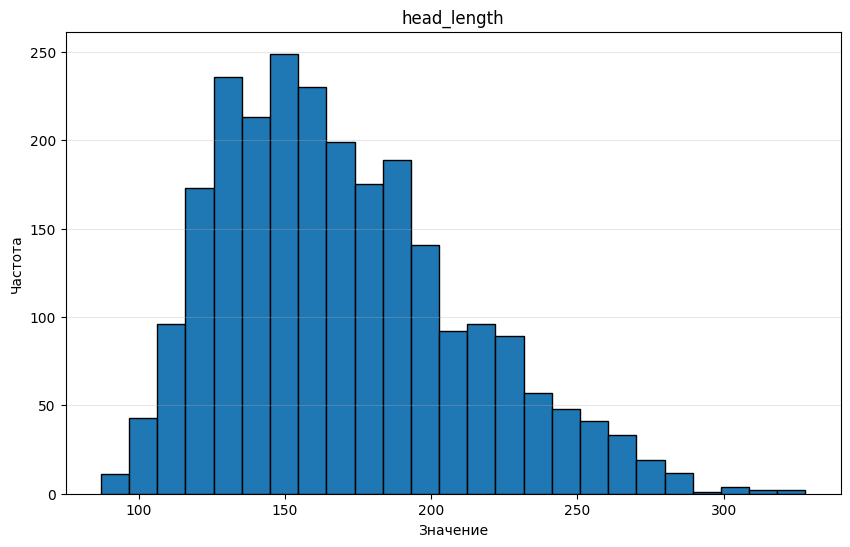

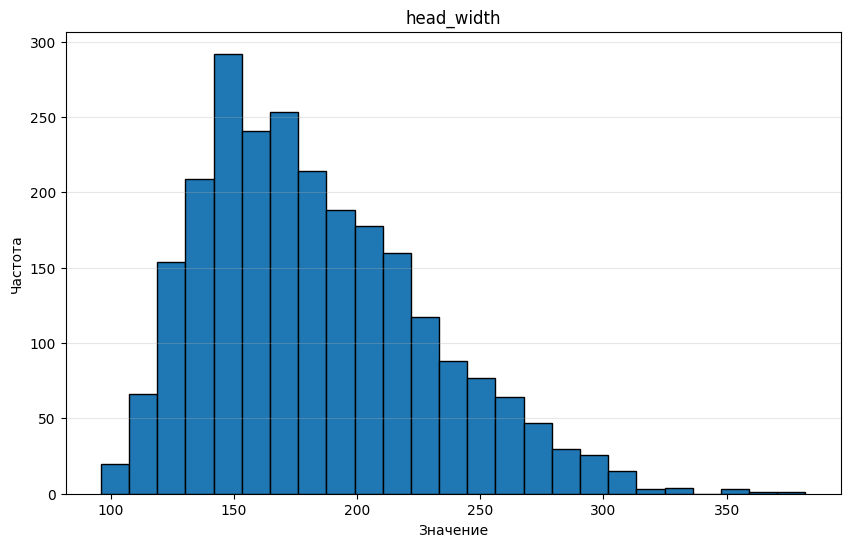

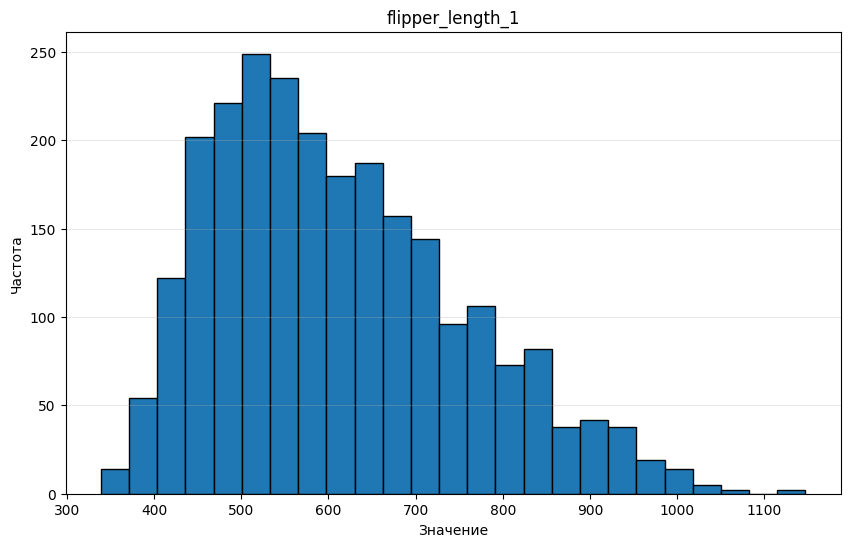

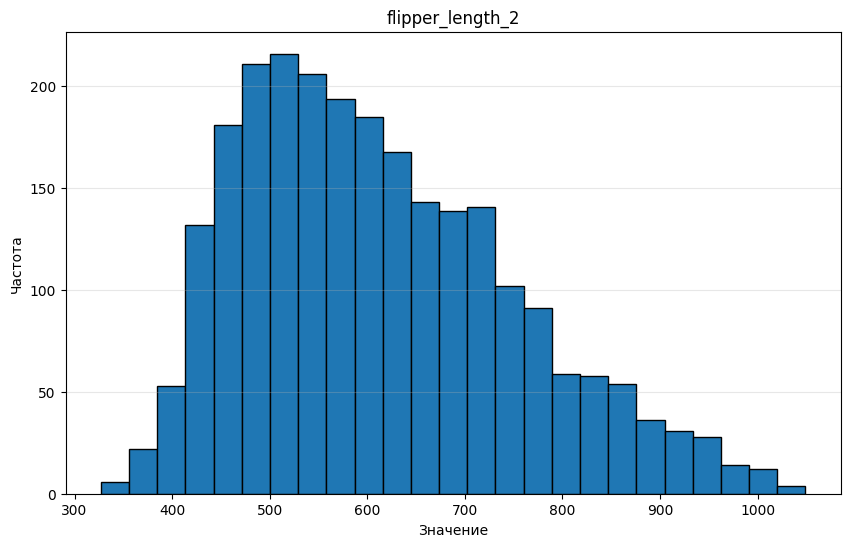

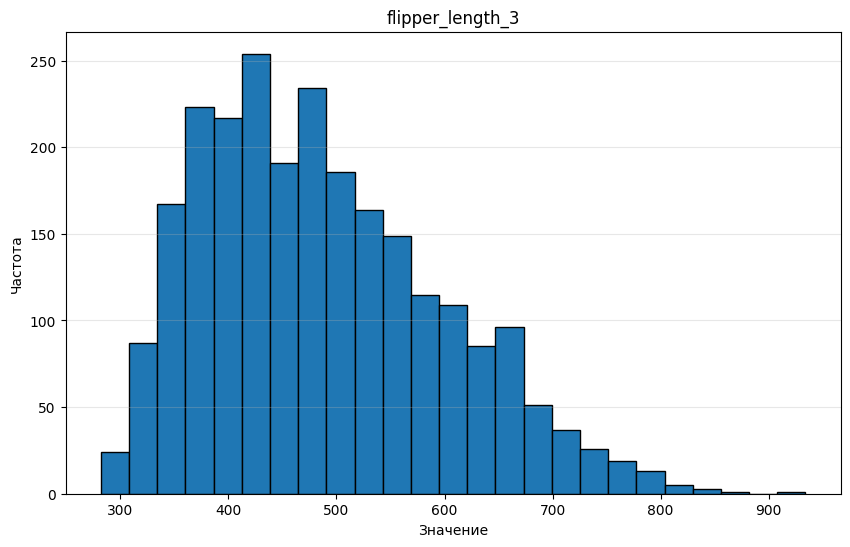

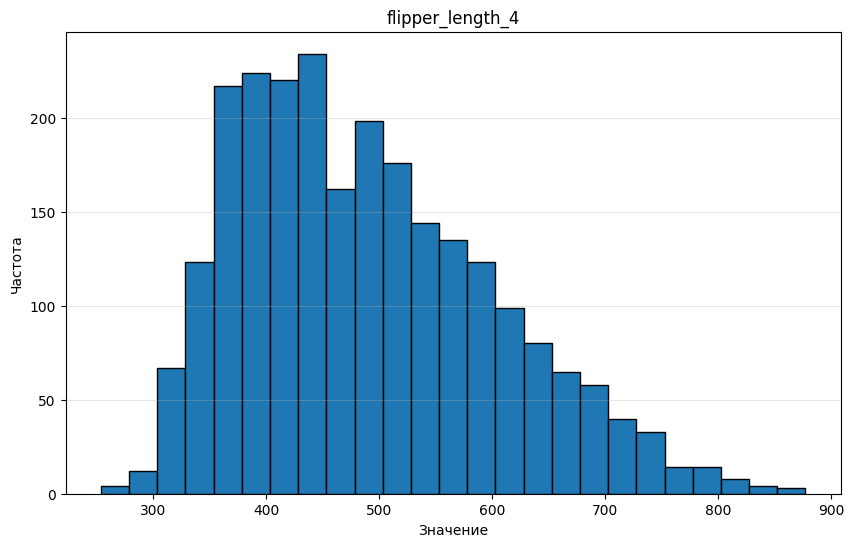

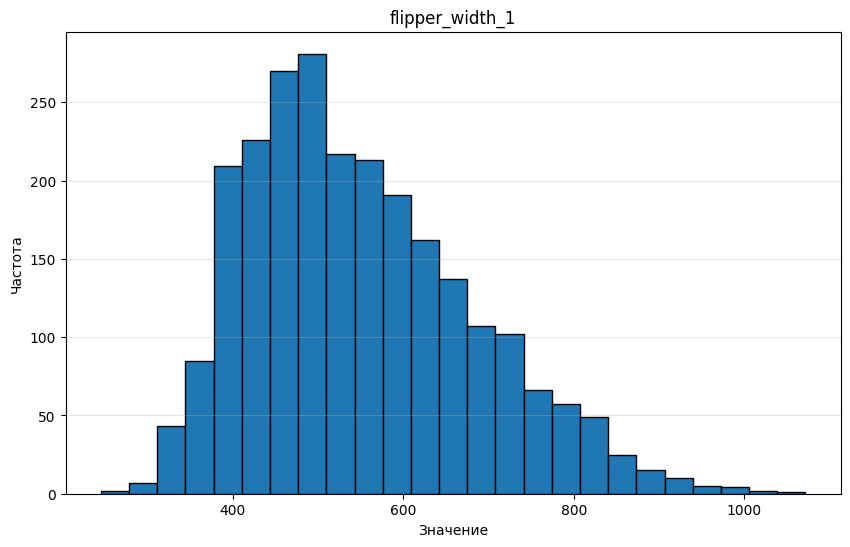

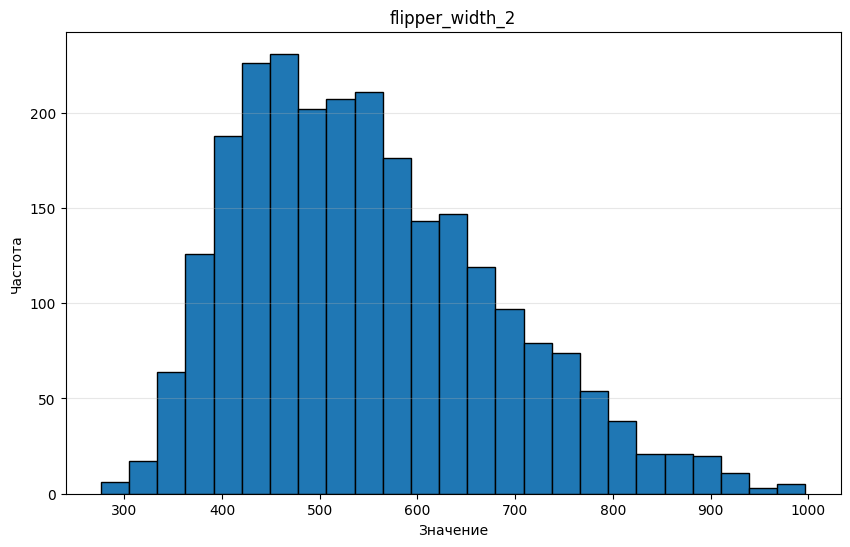

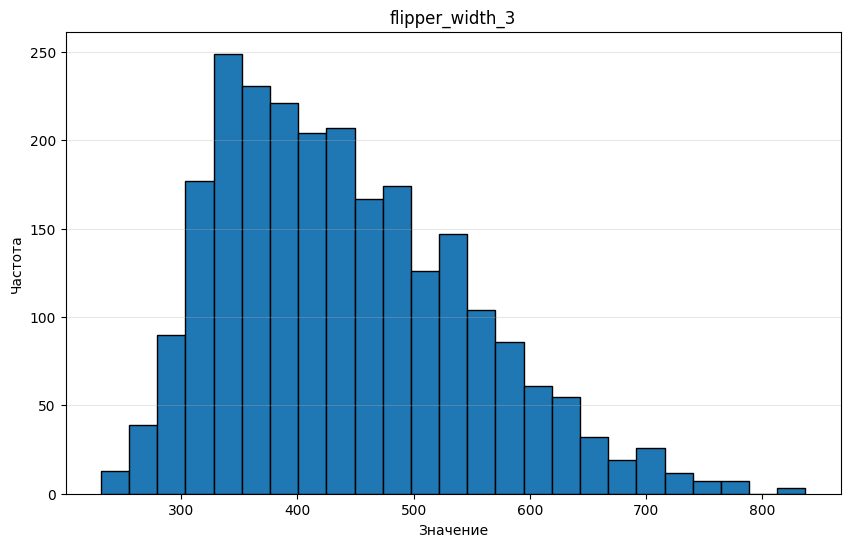

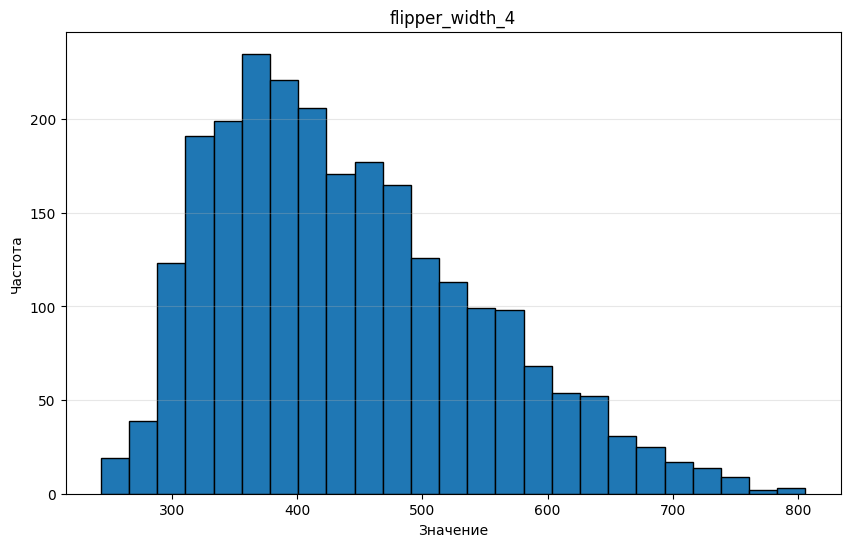

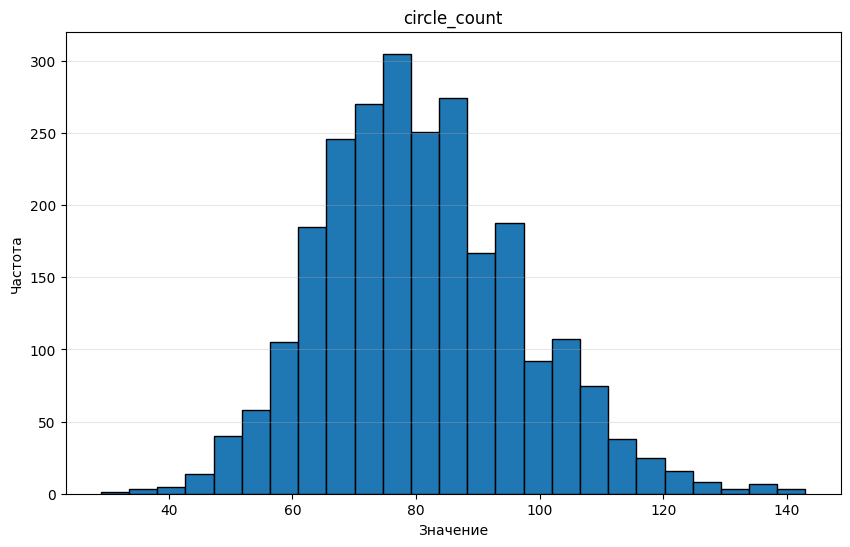

In [24]:
def plot_histograms(df, columns, bins=25):
    """Функция для построения гистограмм"""
    
    for col in columns:
        if col not in df.columns:
            continue
        data = df[col].dropna()
        plt.figure(figsize=(10, 6))
        plt.hist(data, bins=bins, edgecolor='black')
        plt.title(col)
        plt.xlabel('Значение')
        plt.ylabel('Частота')
        plt.grid(axis='y', alpha=0.3)
        plt.show()

plot_histograms(df, features)

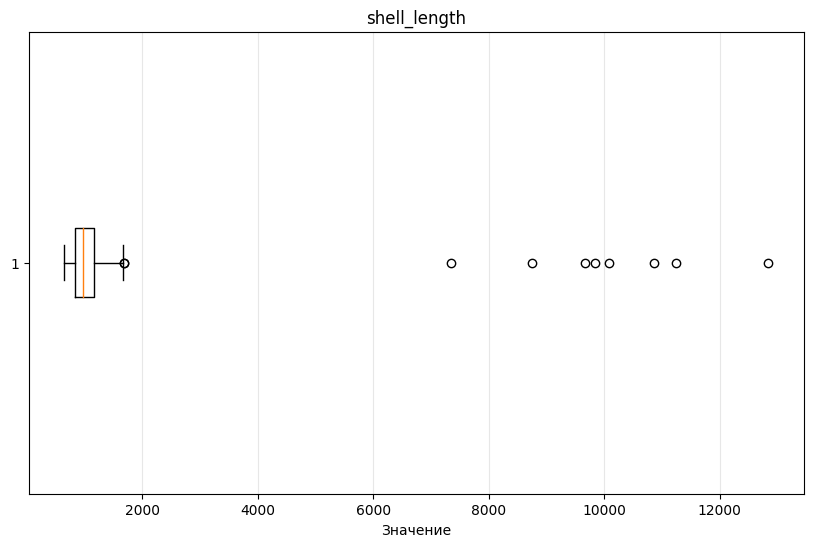

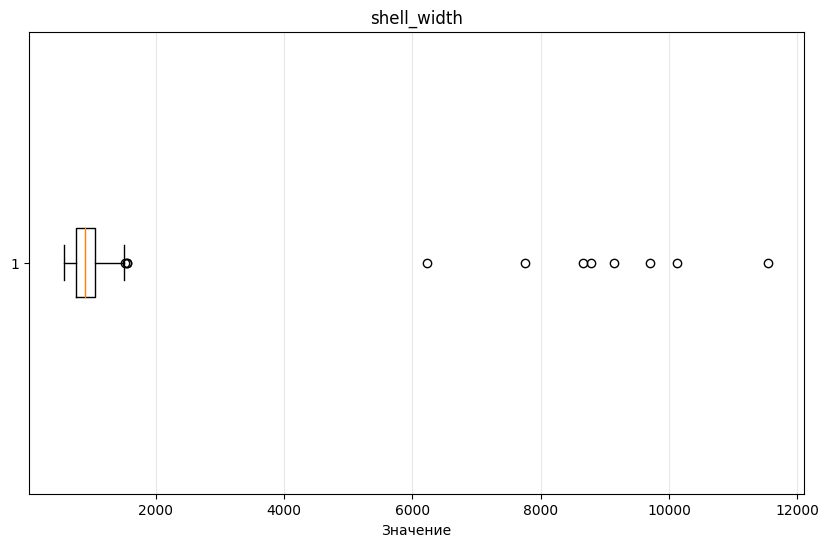

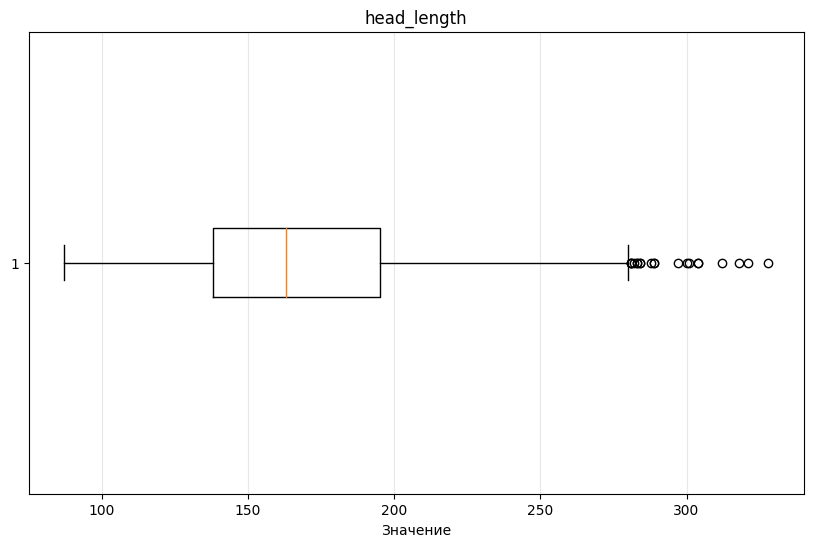

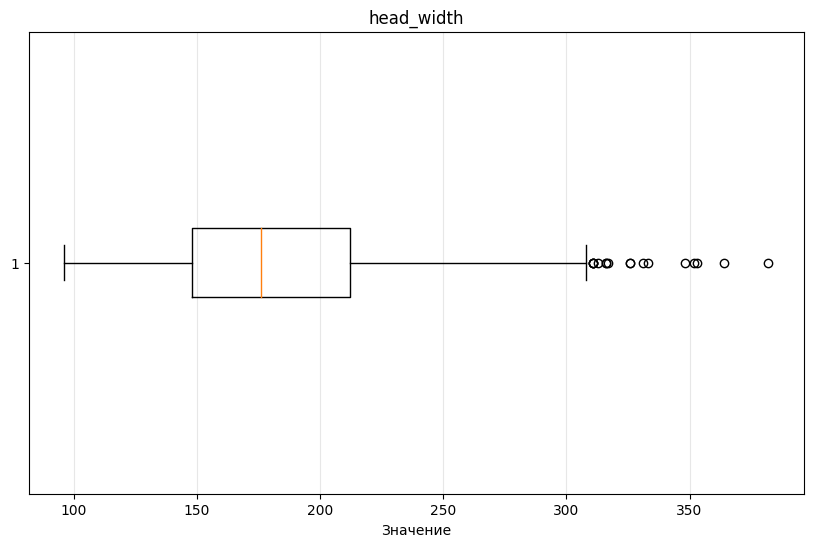

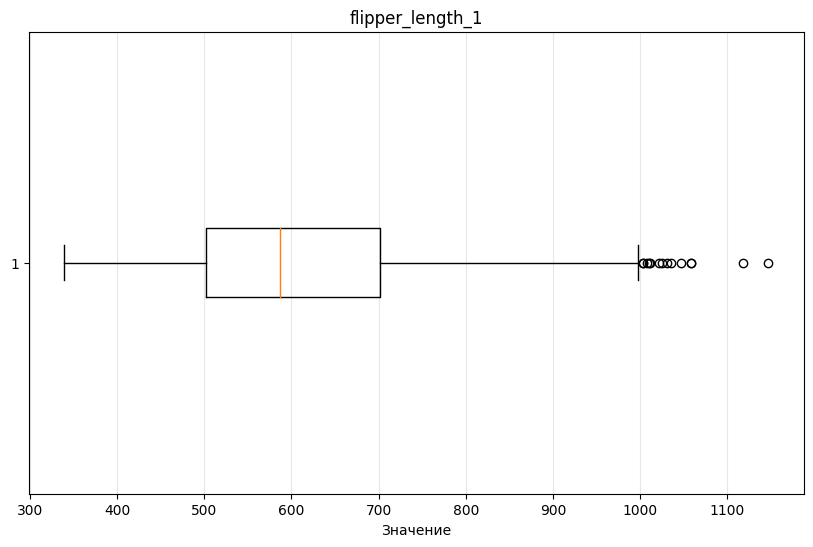

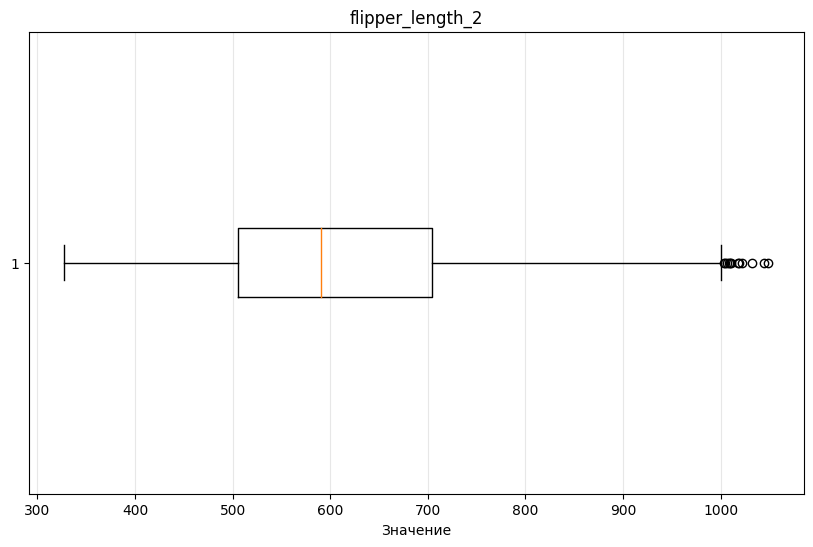

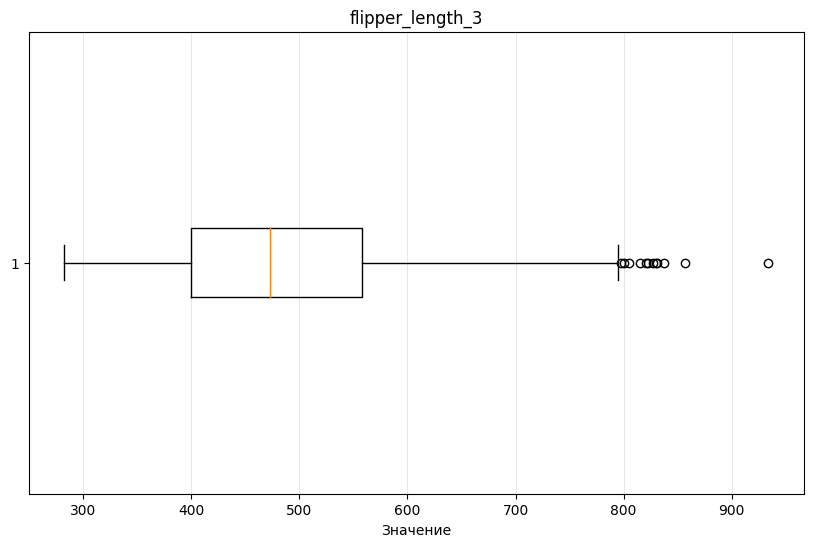

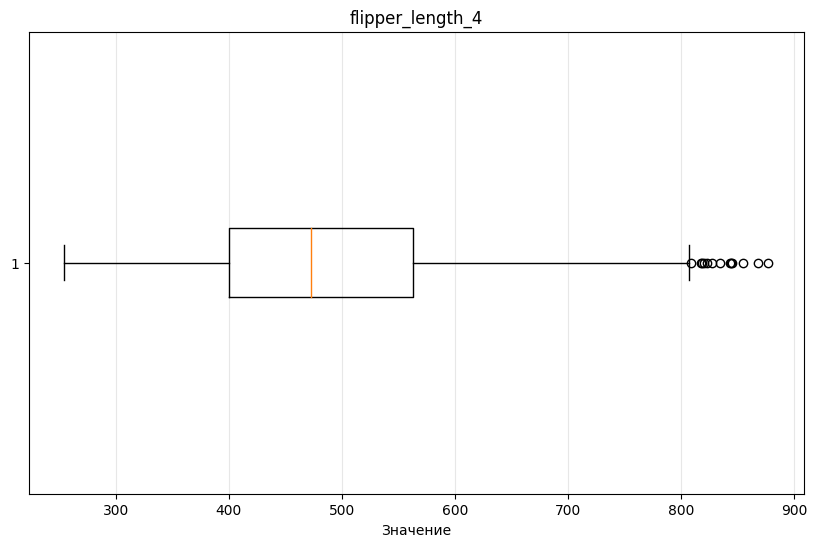

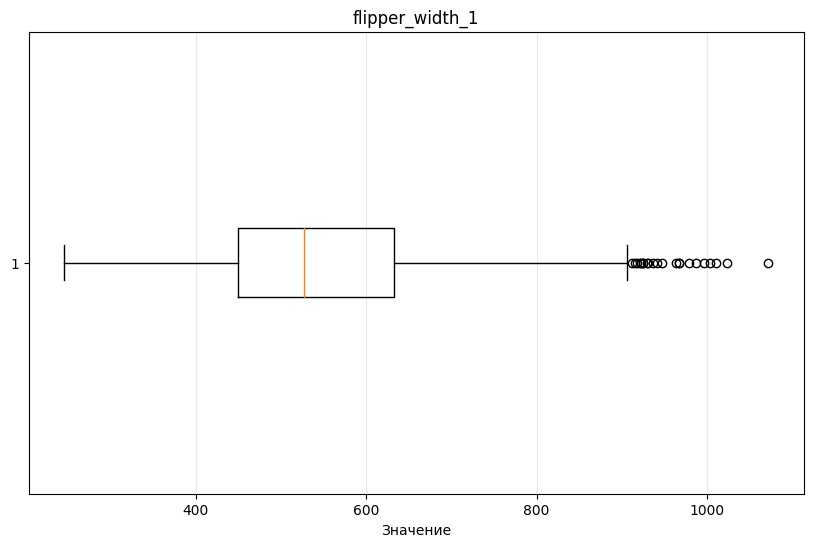

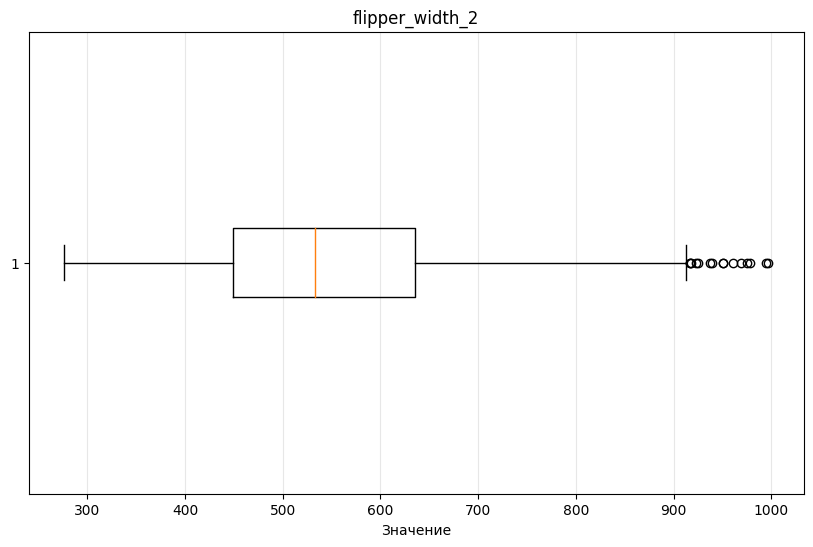

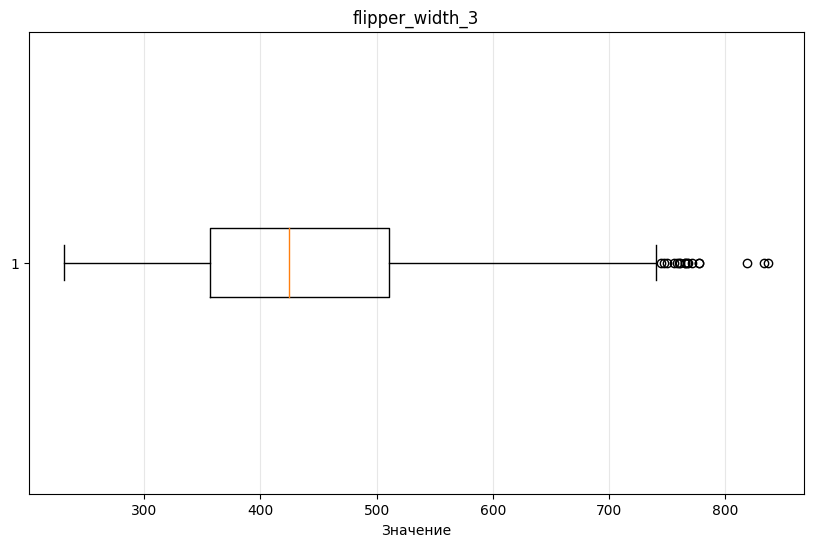

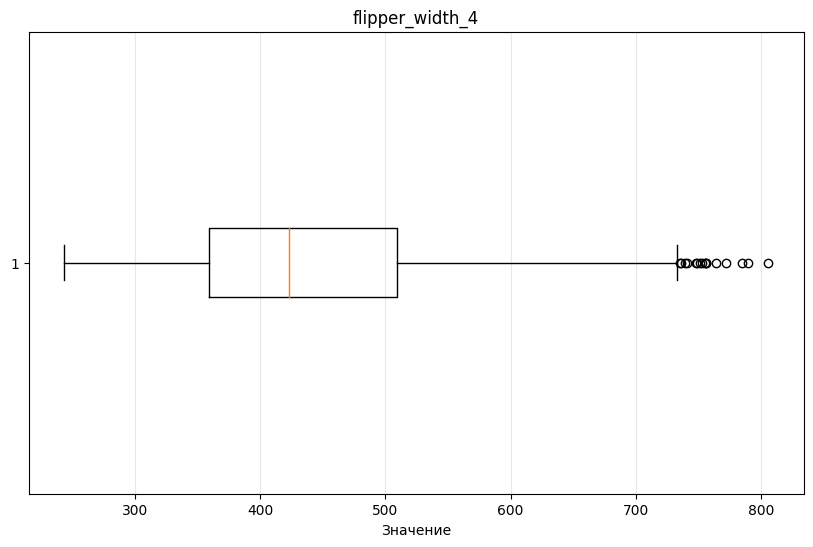

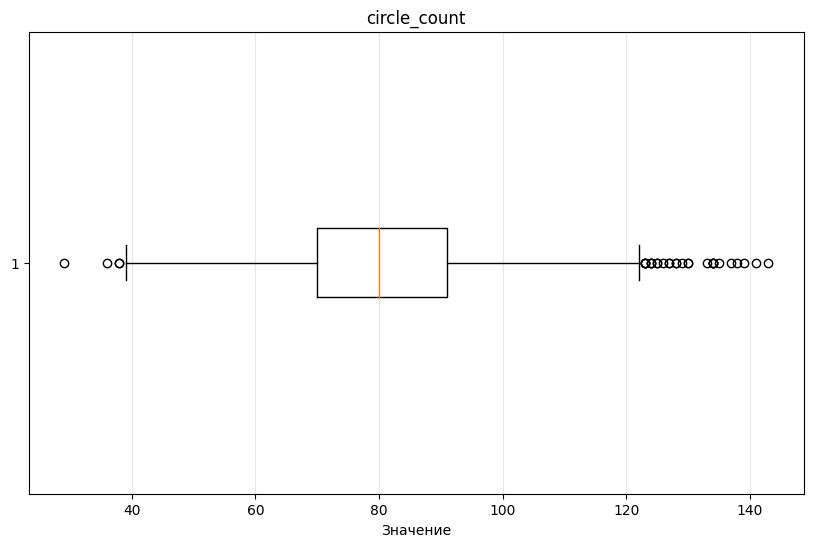

In [25]:
def plot_boxplots(df, columns):
    """Функция для построения коробок с усами"""
    
    for col in columns:
        if col not in df.columns:
            continue
        data = df[col].dropna()
        plt.figure(figsize=(10, 6))
        plt.boxplot(data, vert=False)
        plt.title(col)
        plt.xlabel('Значение')
        plt.grid(axis='x', alpha=0.3)
        plt.show()
        
plot_boxplots(df, features)

In [26]:
def fix_critical_outliers(df):

    df_fixed = df.copy()
    
    df_fixed = df_fixed[df_fixed['weight'] > 0].copy()
    print(f"Удалено строк с weight=0: {(df['weight'] == 0).sum()}")
    

    for col in ['shell_length', 'shell_width']:
        mask = df_fixed[col] > 2000
        print(f'{col}: исправлено {mask.sum()} значений (> 2000)')
        df_fixed.loc[mask, col] = df_fixed.loc[mask, col] / 10
    
    return df_fixed

df = fix_critical_outliers(df)

Удалено строк с weight=0: 3
shell_length: исправлено 8 значений (> 2000)
shell_width: исправлено 8 значений (> 2000)


In [27]:
stats = df[features].describe()
stats.loc['range'] = stats.loc['max'] - stats.loc['min']
stats.loc['cv'] = stats.loc['std'] / stats.loc['mean'] * 100

display(stats.round(2))

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_length_2,flipper_length_3,flipper_length_4,flipper_width_1,flipper_width_2,flipper_width_3,flipper_width_4,circle_count
count,2454.00,2483.00,2448.00,2448.00,2483.00,2483.00,2454.00,2454.00,2483.00,2483.00,2454.00,2454.00,2483.00
mean,1018.39,918.89,169.71,183.31,611.92,611.84,487.22,489.20,549.35,550.20,440.60,440.93,80.92
std,222.00,203.16,41.31,45.47,142.47,138.93,110.38,112.58,131.83,130.88,105.51,104.51,16.23
min,645.00,564.00,87.00,96.00,339.00,327.00,282.00,254.00,245.00,276.00,231.00,243.00,29.00
25%,837.00,751.50,138.00,148.00,501.50,504.50,400.00,400.00,449.00,449.00,357.00,359.00,70.00
50%,979.50,887.00,163.00,176.00,587.00,591.00,473.00,473.00,527.00,533.00,425.00,423.00,80.00
75%,1167.75,1054.00,195.00,212.00,702.00,704.00,558.00,563.00,632.00,635.00,511.00,508.75,91.00
max,1683.00,1554.00,328.00,382.00,1147.00,1049.00,934.00,877.00,1072.00,997.00,837.00,806.00,143.00
range,1038.00,990.00,241.00,286.00,808.00,722.00,652.00,623.00,827.00,721.00,606.00,563.00,114.00
cv,21.80,22.11,24.34,24.80,23.28,22.71,22.65,23.01,24.00,23.79,23.95,23.70,20.05


In [28]:
correlation_matrix = df[['weight', 'shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1',
                         'flipper_length_2', 'flipper_length_3', 'flipper_length_4', 'flipper_width_1',
                         'flipper_width_2', 'flipper_width_3', 'flipper_width_4', 'circle_count']].phik_matrix()

print('Корреляционная матрица с коэффициентом phi_k для переменной weight')
weight_corr = correlation_matrix.loc[correlation_matrix.index != 'weight'][['weight']].sort_values(by='weight', ascending=False)
print(weight_corr)

interval columns not set, guessing: ['weight', 'shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_length_2', 'flipper_length_3', 'flipper_length_4', 'flipper_width_1', 'flipper_width_2', 'flipper_width_3', 'flipper_width_4', 'circle_count']
Корреляционная матрица с коэффициентом phi_k для переменной weight
                    weight
shell_length      0.957884
shell_width       0.934382
flipper_length_1  0.888012
flipper_length_2  0.882113
flipper_length_4  0.880172
flipper_length_3  0.879494
flipper_width_4   0.863711
flipper_width_2   0.862955
flipper_width_3   0.860042
flipper_width_1   0.858829
head_length       0.832480
head_width        0.822959
circle_count      0.513872


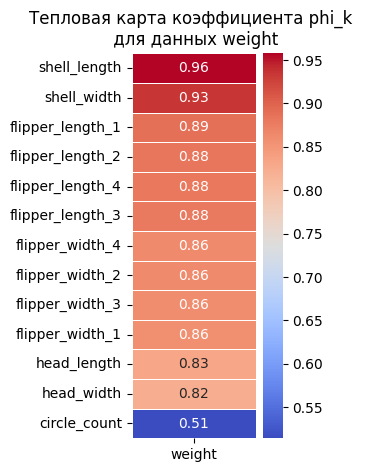


Самая сильная корреляция с рейтингом: shell_length
Коэффициент Phi_k: 0.958


In [29]:
plt.figure(figsize=(2, 5))

data_heatmap = correlation_matrix[['weight']].loc[correlation_matrix.index != 'weight'].sort_values(by='weight', ascending=False)

sns.heatmap(
    data_heatmap,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=True
)
plt.title('Тепловая карта коэффициента phi_k \n для данных weight')
plt.show()

strongest_corr_row = weight_corr.iloc[0]
strongest_feature = weight_corr.index[0]
strongest_value = strongest_corr_row['weight']

print(f'\nСамая сильная корреляция с рейтингом: {strongest_feature}')
print(f'Коэффициент Phi_k: {strongest_value:.3f}')

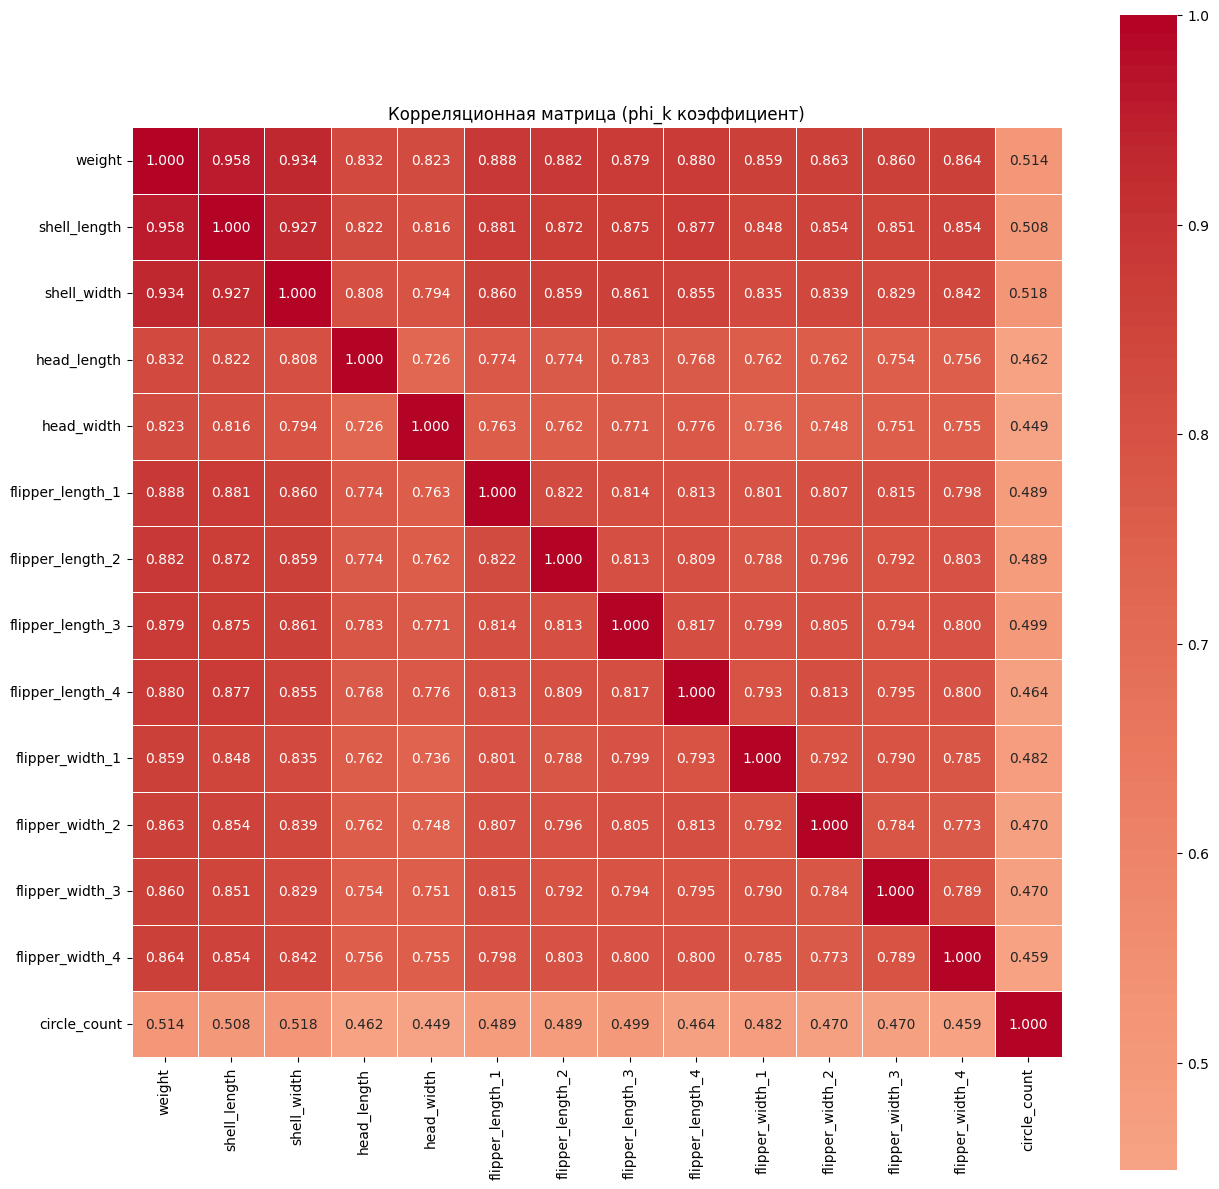

In [30]:
plt.figure(figsize=(15, 15))

sns.heatmap(correlation_matrix, 
            annot=True,
            fmt='.3f',
            linewidths=0.5,
            cbar=True,
            cmap='coolwarm',
            center=0,
            square=True,
            xticklabels=True,
            yticklabels=True)

plt.title('Корреляционная матрица (phi_k коэффициент)')
plt.show()

**Промежуточный вывод:**
1. После приведения записей к единому виду оказалось, что в данных представлено 6 видов черепах. Для дальнейшей работы необхдимо оставить только вид *chelonia mydas* (2829 строк).
2. Не все столбцы в данном датасете имеют влияение на целевую переменную (например, `id`, `binomial_name` и тд), поэтому удалено 6 столбцов. 
    * Новый датафрейм после действия 1-2 содержит 2829 строк, 14 столбцов и занимает 331.5 KB. Удалено 6032 записи.
    
    
3. В новом датафрейме обнаружены пропуски в 8 столбца. Самый важный столбец с пропущенными значениями - `weight` (3, 0,01%). Данные в target были удалены, так как в целевой переменной их не должно быть. Обработку оставшихся произведем после разделения данных на выборки, чтобы не произошла утечка данных.
4. Полных дубликатов выявлено 12.03% (340 строки). Значения во всех столбцах полностью совпадают - это маловероятно, возможно данные отличаются в других столбцах, например, `id` или `binomial_name`, которые мы удалили, но если их оставить, то модель будет учиться на одних и тех же данных нескольо раз, если дубликат попадёт и в train, и в test — метрики будут необъективно высокими. Поэтому удаляем их, оставляя первую запись.
5. По визуализации и статистике видно, что в данных присутствуют аномалии и выбросы (минимальное значение массы - 0, недопустимо), значения длин умножены на 10. При этом максимальное значение массы - 199.96, можно оставить, потому что бывают крупные особи.
6. `shell_length` и `shell_width` имеют значительное расхождение максимальных значений и средних, можно сделать вывод, что ошибка с умножением на 10 только в этих двух признаках.
7. Все признаки показывают сильную положительнуя связь с целевой переменной, присутствует мультиколлинеарность. Поэтому коэффициенты могут не отражают реальную важность признаков, модель становится трудно интерпретируемой, предсказания могут стать менее надёжными. Проведем работу без регяляризации и с ее помощью.

## Предобработка данных

In [31]:
X = df.drop(columns='weight')
y = df['weight']

# выделяем train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# выделяем train и val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, shuffle=True, random_state=42)

# Проверка
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(1489, 13) (497, 13) (497, 13) (1489,) (497,) (497,)


In [32]:
medians = X_train.median()

X_train = X_train.fillna(medians)
X_val = X_val.fillna(medians)
X_test = X_test.fillna(medians)

print(f'Train: {X_train.isnull().sum().sum()}')
print(f'Val: {X_val.isnull().sum().sum()}')
print(f'Test: {X_test.isnull().sum().sum()}')

print("\n Медианы для заполнения (рассчитаны на train):")
print(medians.round(2))

Train: 0
Val: 0
Test: 0

 Медианы для заполнения (рассчитаны на train):
shell_length        966.0
shell_width         878.0
head_length         162.0
head_width          175.0
flipper_length_1    583.0
flipper_width_1     520.0
flipper_length_2    584.0
flipper_width_2     529.0
flipper_length_3    469.0
flipper_width_3     421.0
flipper_length_4    469.0
flipper_width_4     419.0
circle_count         80.0
dtype: float64


In [33]:
def standardize_data(X_train, X_val, X_test):
    mean = X_train.mean()
    std = X_train.std().replace(0, 1)
    X_train_standardize = (X_train - mean) / std
    X_val_standardize = (X_val - mean) / std
    X_test_standardize = (X_test - mean) / std
    
    params = {'mean': mean, 'std': std}
    
    return X_train_standardize, X_val_standardize, X_test_standardize, params

X_train_standardize, X_val_standardize, X_test_standardize, params = standardize_data(X_train, X_val, X_test)

# проверка: вывод среднего и стандартного отклонения полученных выборок
print("Train mean (avg):", X_train_standardize.mean().mean().round(2))
print("Train std (avg):", X_train_standardize.std().mean().round(2))
print("Val mean (avg):", X_val_standardize.mean().mean().round(2))
print("Val std (avg):", X_val_standardize.std().mean().round(2))
print("Test mean (avg):", X_test_standardize.mean().mean().round(2))
print("Test std (avg):", X_test_standardize.std().mean().round(2))

Train mean (avg): 0.0
Train std (avg): 1.0
Val mean (avg): 0.04
Val std (avg): 1.03
Test mean (avg): 0.07
Test std (avg): 1.01


In [34]:
def normalize_data(X_train, X_val, X_test):
    min = X_train.min()
    max = X_train.max()
    range = (max - min).replace(0, 1)
    
    X_train_norm = (X_train - min) / range
    X_val_norm = (X_val - min) / range
    X_test_norm = (X_test - min) / range
    
    params = {'min': min, 'max': max}
    
    return X_train_norm, X_val_norm, X_test_norm, params

In [35]:
def no_scaling(X_train, X_val, X_test):
    params = {'method': 'none'}
    return X_train.copy(), X_val.copy(), X_test.copy(), params

In [36]:
def prepare_all_datasets(X_train, X_val, X_test):

    datasets = {}
    all_params = {}
    
    X_tr, X_va, X_te, params = standardize_data(X_train, X_val, X_test)
    datasets['standardized'] = {'train': X_tr, 'val': X_va, 'test': X_te}
    all_params['standardized'] = params
    
    X_tr, X_va, X_te, params = normalize_data(X_train, X_val, X_test)
    datasets['normalized'] = {'train': X_tr, 'val': X_va, 'test': X_te}
    all_params['normalized'] = params
    
    X_tr, X_va, X_te, params = no_scaling(X_train, X_val, X_test)
    datasets['no_scaling'] = {'train': X_tr, 'val': X_va, 'test': X_te}
    all_params['no_scaling'] = params

    
    return datasets, all_params

datasets, scaling_params = prepare_all_datasets(X_train, X_val, X_test)

**Промежуточный вывод:**
1. Данные разделены на выборки: обучающую (60%), валидационную (20%) и тестовую (20%).
2. Пропуски заполнены медианным значением, так как медиана устойчива к выбросам, в отличие от среднего арифметического, и она рассчитана только по обучающей выборке.
3. Все необходимые параметры для функций стандартизации, мин-макс расчитаны только на обущающей выборкке, чтобы не роизошла утечка данных.
4. Собрано три датасета с тремя выборками с разнными способбами масштабирования.

## Обучение моделей

In [37]:
dummy_mean = y_train.mean()

y_pred_train = np.full(len(y_train), dummy_mean)
y_pred_val = np.full(len(y_val), dummy_mean)
y_pred_test = np.full(len(y_test), dummy_mean)

In [38]:
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{name}:")
    print(f"MAE: {mae:.2f} кг")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²: {r2:.4f}")
    
    return {'MAE': mae, 'MAPE': mape, 'R2': r2}


In [39]:
dummy_results = {
    'train': print_metrics(y_train, y_pred_train, 'Train'),
    'val': print_metrics(y_val, y_pred_val, 'Validation'),
    'test': print_metrics(y_test, y_pred_test, 'Test')
}


Train:
MAE: 28.45 кг
MAPE: 32.42%
R²: 0.0000

Validation:
MAE: 29.35 кг
MAPE: 32.44%
R²: -0.0029

Test:
MAE: 27.94 кг
MAPE: 30.41%
R²: -0.0068


In [40]:
linreg = LinearRegression()
linreg.fit(X_train_standardize, y_train)

coeff_df = pd.DataFrame({
    'Признак': X_train_standardize.columns,
    'Коэффициент': np.round(linreg.coef_, 4)
}).sort_values('Коэффициент', ascending=False)
display(coeff_df)

,Признак,Коэффициент
0,shell_length,9.9355
1,shell_width,7.1721
4,flipper_length_1,3.1650
6,flipper_length_2,2.6489
8,flipper_length_3,1.7873
5,flipper_width_1,1.7387
7,flipper_width_2,1.6866
2,head_length,1.6842
3,head_width,1.6473
10,flipper_length_4,1.6318


In [41]:
alpha_values = [0.001, 0.01, 0.1, 1.0]

lasso_models = {}
for alpha in alpha_values:
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    model.fit(X_train_standardize, y_train)

    lasso_models[alpha] = model
    
    coeff_df = pd.DataFrame({
        'Признак': X_train_standardize.columns,
        'Коэффициент': np.round(model.coef_, 4)
    }).sort_values('Коэффициент', ascending=False)
    
    display(coeff_df)

,Признак,Коэффициент
0,shell_length,9.9327
1,shell_width,7.1813
4,flipper_length_1,3.1688
6,flipper_length_2,2.6491
8,flipper_length_3,1.7858
5,flipper_width_1,1.7410
2,head_length,1.6860
7,flipper_width_2,1.6854
3,head_width,1.6497
10,flipper_length_4,1.6263


,Признак,Коэффициент
0,shell_length,9.9408
1,shell_width,7.1869
4,flipper_length_1,3.1671
6,flipper_length_2,2.6471
8,flipper_length_3,1.7836
5,flipper_width_1,1.7388
2,head_length,1.6831
7,flipper_width_2,1.6826
3,head_width,1.6469
10,flipper_length_4,1.6250


,Признак,Коэффициент
0,shell_length,10.0463
1,shell_width,7.2404
4,flipper_length_1,3.1436
6,flipper_length_2,2.6207
8,flipper_length_3,1.7569
5,flipper_width_1,1.7103
2,head_length,1.6523
7,flipper_width_2,1.6507
3,head_width,1.6152
10,flipper_length_4,1.6151


,Признак,Коэффициент
0,shell_length,10.7178
1,shell_width,7.7305
4,flipper_length_1,2.9858
6,flipper_length_2,2.4454
8,flipper_length_3,1.5706
10,flipper_length_4,1.4949
5,flipper_width_1,1.4798
7,flipper_width_2,1.3936
9,flipper_width_3,1.3806
2,head_length,1.3537


In [42]:
ridge_models = {}
for alpha in alpha_values:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train_standardize, y_train)

    ridge_models[alpha] = model
    
    coeff_df = pd.DataFrame({
        'Признак': X_train_standardize.columns,
        'Коэффициент': np.round(model.coef_, 4)
    }).sort_values('Коэффициент', ascending=False)
    
    display(coeff_df)

,Признак,Коэффициент
0,shell_length,9.9355
1,shell_width,7.1720
4,flipper_length_1,3.1650
6,flipper_length_2,2.6489
8,flipper_length_3,1.7873
5,flipper_width_1,1.7387
7,flipper_width_2,1.6866
2,head_length,1.6842
3,head_width,1.6473
10,flipper_length_4,1.6318


,Признак,Коэффициент
0,shell_length,9.9348
1,shell_width,7.1718
4,flipper_length_1,3.1651
6,flipper_length_2,2.6490
8,flipper_length_3,1.7875
5,flipper_width_1,1.7388
7,flipper_width_2,1.6868
2,head_length,1.6843
3,head_width,1.6474
10,flipper_length_4,1.6319


,Признак,Коэффициент
0,shell_length,9.9281
1,shell_width,7.1690
4,flipper_length_1,3.1658
6,flipper_length_2,2.6502
8,flipper_length_3,1.7887
5,flipper_width_1,1.7399
7,flipper_width_2,1.6881
2,head_length,1.6851
3,head_width,1.6481
10,flipper_length_4,1.6331


,Признак,Коэффициент
0,shell_length,9.8615
1,shell_width,7.1415
4,flipper_length_1,3.1726
6,flipper_length_2,2.6617
8,flipper_length_3,1.8010
5,flipper_width_1,1.7500
7,flipper_width_2,1.7015
2,head_length,1.6929
3,head_width,1.6544
10,flipper_length_4,1.6443


In [43]:
loss_functions = ['squared_error', 'huber', 'epsilon_insensitive']
sgd_models = {}

for loss in loss_functions:
    model = SGDRegressor(loss=loss, max_iter=5000, tol=1e-3, random_state=42)
    model.fit(X_train_standardize, y_train)
    
    sgd_models[loss] = model
    
    coeff_df = pd.DataFrame({
        'Признак': X_train_standardize.columns,
        'Коэффициент': np.round(model.coef_, 4)
    }).sort_values('Коэффициент', ascending=False)
    
    display(coeff_df)

,Признак,Коэффициент
0,shell_length,9.0638
1,shell_width,7.1558
4,flipper_length_1,3.2646
6,flipper_length_2,2.7647
8,flipper_length_3,1.9073
5,flipper_width_1,1.8135
7,flipper_width_2,1.8037
2,head_length,1.7534
10,flipper_length_4,1.7217
3,head_width,1.6995


,Признак,Коэффициент
0,shell_length,3.3512
1,shell_width,3.2380
4,flipper_length_1,3.0409
6,flipper_length_2,3.0201
5,flipper_width_1,2.8765
10,flipper_length_4,2.8705
8,flipper_length_3,2.8205
7,flipper_width_2,2.7623
11,flipper_width_4,2.6626
9,flipper_width_3,2.5207


,Признак,Коэффициент
0,shell_length,8.2902
1,shell_width,5.8867
4,flipper_length_1,3.1734
6,flipper_length_2,2.8768
8,flipper_length_3,2.3948
11,flipper_width_4,2.0993
7,flipper_width_2,2.0670
5,flipper_width_1,2.0387
2,head_length,1.7374
10,flipper_length_4,1.7322


In [44]:
def calculate_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

In [45]:
results = []
y_pred_val = linreg.predict(X_val_standardize)
metrics = calculate_metrics(y_val, y_pred_val)
results.append({
    'Модель': 'LinearRegression',
    'Масштабирование': 'standardized',
    'Гиперпараметры': '-',
    **metrics
})

In [46]:
for alpha in alpha_values:
    model = lasso_models[alpha]
    
    y_pred_val = model.predict(X_val_standardize)
    metrics = calculate_metrics(y_val, y_pred_val)
    results.append({
        'Модель': f'Lasso (alpha={alpha})',
        'Масштабирование': 'standardized',
        'Гиперпараметры': f'alpha={alpha}',
        **metrics
    })

In [47]:
for alpha in alpha_values:
    model = ridge_models[alpha]
    
    y_pred_val = model.predict(X_val_standardize)
    metrics = calculate_metrics(y_val, y_pred_val)
    results.append({
        'Модель': f'Ridge (alpha={alpha})',
        'Масштабирование': 'standardized',
        'Гиперпараметры': f'alpha={alpha}',
        **metrics
    })

In [48]:
for loss in loss_functions:
    model = sgd_models[loss]
    
    y_pred_val = model.predict(X_val_standardize)
    metrics = calculate_metrics(y_val, y_pred_val)
    results.append({
        'Модель': f'SGDRegressor (loss={loss})',
        'Масштабирование': 'standardized',
        'Гиперпараметры': f"loss='{loss}'",
        **metrics
    })

In [49]:
results_df = pd.DataFrame(results)

cols_order = ['Модель', 'Масштабирование', 'Гиперпараметры', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE']
results_df = results_df[cols_order]

for col in ['MAE', 'MSE', 'RMSE', 'R2', 'MAPE']:
    results_df[col] = results_df[col].round(4)
    
results_df = results_df.sort_values('MAE').reset_index(drop=True)

display(results_df)

,Модель,Масштабирование,Гиперпараметры,MAE,MSE,RMSE,R2,MAPE
0,Lasso (alpha=0.1),standardized,alpha=0.1,3.8566,25.6706,5.0666,0.9804,4.1927
1,Ridge (alpha=1.0),standardized,alpha=1.0,3.8583,25.5707,5.0567,0.9805,4.2120
2,LinearRegression,standardized,-,3.8584,25.5727,5.0569,0.9805,4.2128
3,Ridge (alpha=0.001),standardized,alpha=0.001,3.8584,25.5727,5.0569,0.9805,4.2128
4,Ridge (alpha=0.01),standardized,alpha=0.01,3.8584,25.5726,5.0569,0.9805,4.2128
5,Ridge (alpha=0.1),standardized,alpha=0.1,3.8584,25.5724,5.0569,0.9805,4.2128
6,Lasso (alpha=0.01),standardized,alpha=0.01,3.8585,25.5786,5.0575,0.9805,4.2114
7,Lasso (alpha=0.001),standardized,alpha=0.001,3.8587,25.5713,5.0568,0.9805,4.2132
8,SGDRegressor (loss=squared_error),standardized,loss='squared_error',3.8610,25.5690,5.0566,0.9805,4.2002
9,SGDRegressor (loss=epsilon_insensitive),standardized,loss='epsilon_insensitive',3.8950,27.8436,5.2767,0.9788,4.0620


**Промежуточный вывод:**
1. Построена дамми модель, она предсказывает среднее значение массы из обучающей выборки, не используя признаки. Это минимальный барьер качества. Коэффициент детерминации равный 0 подтверждает, что модель не использует информацию о признаках. Если последующие модели покажут метрики хуже, чем Dummy - это сигнал о проблеме в предобработке или обучении.
2. Модели обучены:
    * Lasso (L1): при увеличении alpha коэффициенты сжимаются к нулю. При alpha=1.0 признак `circle_count` практически близок к нулю (0.3), что демонстрирует свойство L1-регуляризации отбирать признаки.
    * Ridge (L2): коэффициенты остаются стабильными при разных alpha, что характерно для L2-регуляризации (сжатие без обнуления).
    
3. По собранному датафрейму можно сделать вывод, что лучшая модель - это Lasso (alpha=0.1), она устойчва к малым ошибкам. Ridge (alpha=1.0) и LinearRegression показали близкие метрики к  Lasso (alpha=0.1), следовательно переобучения нет, данные хорошо очищены.

## Сравнение моделей на валидационной выборке

In [50]:
best_model = results_df.iloc[0]['Модель']
best_model_val_mae = results_df.iloc[0]['MAE']
best_model_val_r2 = results_df.iloc[0]['R2']
best_model_val_mape = results_df.iloc[0]['MAPE']

print(f'\nЛучшая модель по валидации: {best_model}')
print(f'Метрики на валидации:')
print(f'MAE: {best_model_val_mae:.4f}')
print(f'R²: {best_model_val_r2:.4f}')
print(f'MAPE: {best_model_val_mape:.2f}%')


Лучшая модель по валидации: Lasso (alpha=0.1)
Метрики на валидации:
MAE: 3.8566
R²: 0.9804
MAPE: 4.19%


1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

**Сравнение моделей на валидационной выборке:**


По результатам сравненияя на валидационной выборке базовой модели дамми и лучшей Lasso (alpha=0.1) произошли значительные улучшения. MAE улучшился в 7.2 раза (до 3.86 кг), R² +0.97 и MAPE уменьшился в 7.3 раз. Результат базовой модели улучшен существенно по всем метрикам. Целевые показатели (MAE ≤ 5 кг, R² ≥ 0.97) достигнуты. Выбранная модель будет проверена на тестовой выборке для финальной оценки.

## Проверка лучшей модели на тестовой выборке

In [51]:
best_model = lasso_models[0.1]
y_pred_test = best_model.predict(X_test_standardize)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

print(f'MAE: {test_mae:.4f}')
print(f'MSE: {test_mse:.4f}')
print(f'RMSE: {test_rmse:.4f}')
print(f'R²: {test_r2:.4f}')
print(f'MAPE: {test_mape:.2f}%')

MAE: 3.8232
MSE: 26.3250
RMSE: 5.1308
R²: 0.9779
MAPE: 4.09%


**Промежуточный вывод:**
* Результат MAE <= 5, как и коэффициент детерминации чуть больше 0.97, результат достигрут. MAPE 4% < 10% - это хроший результат. Если сравнивать резултат на валидационной и тестовой выборке, MAE +24 кг, коэффицинт детерминации -0.97 и MAPE 4% < 20%, и метрики показывают стабильность, следовательно переобучения нет, модель обобщает данные корректно.
* Модель соответствует требованиям заказчика, ее можно рекмендовать к внедрению, но с некторыми улучшениями и более глубокой проработкой метрик. 

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [52]:
best_model = lasso_models[0.1]
feature_names = X_train_standardize.columns.tolist()

coefficients = best_model.coef_
abs_coefficients = np.abs(coefficients)

importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    'Абс. значение': abs_coefficients
}).sort_values('Абс. значение', ascending=False).reset_index(drop=True)

print('\nВажность признакков по абсолютному весу:')
display(importance_df.round(4))


Важность признакков по абсолютному весу:


,Признак,Коэффициент,Абс. значение
0,shell_length,10.0463,10.0463
1,shell_width,7.2404,7.2404
2,flipper_length_1,3.1436,3.1436
3,flipper_length_2,2.6207,2.6207
4,flipper_length_3,1.7569,1.7569
5,flipper_width_1,1.7103,1.7103
6,head_length,1.6523,1.6523
7,flipper_width_2,1.6507,1.6507
8,head_width,1.6152,1.6152
9,flipper_length_4,1.6151,1.6151


Первое и второе место занимает длина и ширина панциря, это говорит о том, что данные габариты является самым сильным предикатором массы. Это абсолютно верно, так как их размер хорошо отражает общий объем тела и, следовательно, массу.

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [53]:
def predict_turtle_weight(features_dict, coef, intercept, mean, std, medians):

    X_new = pd.DataFrame([features_dict])

    X_new = X_new.fillna(medians)

    X_scaled = (X_new - mean) / std

    y_pred = X_scaled.values @ coef + intercept
    
    return float(y_pred[0])

test_idx = 0
X_test_sample = X_test.iloc[test_idx]
y_test_actual = y_test.iloc[test_idx]

features_dict = X_test_sample.to_dict()

y_pred_function = predict_turtle_weight(
    features_dict=features_dict,
    coef=lasso_models[0.1].coef_,
    intercept=lasso_models[0.1].intercept_,
    mean=scaling_params['standardized']['mean'],
    std=scaling_params['standardized']['std'],
    medians=medians
)

print(f'Предсказание функцией: {y_pred_function:.4f} кг')

Предсказание функцией: 46.7277 кг


**Функция прогнозирования массы черепахи:**
1. Получение входных данных (DataFrame с 13 признаками)
2. Заполнение пропусков:
    * Заменить NaN на медианы из обучающей выборки
3. Стандартизация признаков
    * Формула: X_scaled = (X - mean) / std 
4. Линейная комбинация с коэффициентами
    * Формула: y_pred = X_scaled @ coef_ + intercept_
    * coef_ и intercept_ из обученной модели
5. Возврат прогноза
    * Масса черепахи в килограммах
    

## Общие выводы и рекомендации по дальнейшей работе

* В рамках проекта были обучены и сравнены архитектуры линейных моделей: LinearRegression (Базовая линейная регрессия), Lasso (L1) с alpha = 0.001, 0.01, 0.1, 1.0, Ridge (L2), SGDRegressor и базовая модель (Dummy), которая предсказывает среднее значения массы. В работе использовалось три способа масштабирования: без масштабирования, нормализация [0, 1], стандартизация.
* Итоговые результаты показали, что Lasso (alpha=0.1) является лучшей модлью и метрики улучшились MAE <= 5, коэффициент детерминации 0.9779 и MAPE 4%, что меньше 20%.
* Данные были проверены на переобучение, которого не оказалось, следовательн модель имеет хорошие коэффициенты.
* Рекомендуется условное внедрение, так как выполнены целевые метрики.
* Архитектура и способ обработки признаков:
    * Функция потерь устойчива к малым ошибкам и игнорирует шум,
    * Масштабирование (стандартизация) показала, что коэффициенты сравнимы, устойчивы к выбросам,
    * Обработка пропусков медианным значением 
    Лучшие метрики:
    На валидационной выборке:
    Метрики на валидации:
    MAE: 3.8566
    R²: 0.9804
    MAPE: 4.19%
    На тестовой выборке:
    MAE: 3.8232
    MSE: 26.3250
    RMSE: 5.1308
    R²: 0.9779
    MAPE: 4.09%
* Наиболее важные признаки - `shell_length` и `shell_width` - длина и ширина панциря, то есть это самый важный предиктор массы. Таблица признаков показала, что можно брать для упрощения сбора данных.
* Перспективы для других видов черепах есть, например, габариты тела коррелируют с массой у большинства видов.